# Testing Cases Outline

Here we asses how each texture feature differs across the bernoulli settings. Paragraph reports for each feature and plots; what do they highlight in any sudden patterns out of the randomness (look at certain cases of the samples), how are they affected by bernoulli settings.

In [33]:
from src.glcm_features.features import (compute_autocorrelation,      
                                        compute_cluster_prominence, 
                                        compute_cluster_shade,
                                        compute_cluster_tendency,
                                        compute_difference_average, 
                                        compute_difference_entropy,
                                        compute_difference_variance,
                                        compute_entropy,
                                        compute_information_measure_correlation_1,
                                        compute_information_measure_correlation_2,
                                        compute_inverse_difference,
                                        compute_inverse_difference_norm,
                                        compute_inverse_difference_moment,
                                        compute_inverse_difference_moment_norm,
                                        compute_inverse_variance,
                                        compute_joint_average,
                                        compute_maximum_probability,
                                        compute_maximal_correlation_coefficient,
                                        compute_sum_average,
                                        compute_sum_entropy,
                                        compute_sum_of_squares,
                                        compute_sum_variance
                                        )

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import patches
from matplotlib import axes
from skimage.feature import graycomatrix, graycoprops

## Image Generation
randomly generated 8x8 images using bernoulli iid for each pixel. 
take over 100 samples of images generated for each bernoulli setting and record the mean 

$p \in {0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9}$

In [34]:
def compute_samples(bernoulli_settings, num_samples=100, size=(8, 8)):
    image_samples = {}
    sample_features = {}
    
    for p in bernoulli_settings:
        samples_list = []
        features_list = []

        for i in range(num_samples):
            image = (np.random.rand(*size) < p).astype(int)
            samples_list.append(image)
            
            distances = [1]
            N = 4
            
            glcm0 = graycomatrix(image, distances=distances, angles=[0], levels=N, symmetric=True)
            glcm1 = graycomatrix(image, distances=distances, angles=[np.pi/4], levels=N, symmetric=True)
            glcm2 = graycomatrix(image, distances=distances, angles=[np.pi/2], levels=N, symmetric=True)
            glcm3 = graycomatrix(image, distances=distances, angles=[3 * np.pi/4], levels=N, symmetric=True)
            
            mean_glcm = (np.squeeze(glcm0) + np.squeeze(glcm1) + np.squeeze(glcm2) + np.squeeze(glcm3)) / 4
            glcm = mean_glcm / np.sum(mean_glcm)
            glcm_4d = (glcm0 + glcm1 + glcm2 + glcm3) / 4
            glcm_4d = glcm_4d / np.sum(mean_glcm)
            
            contrast = float(graycoprops(glcm_4d, 'contrast'))
            energy = float(graycoprops(glcm_4d, 'energy'))
            homogeneity = float(graycoprops(glcm_4d, 'homogeneity'))
            correlation = float(graycoprops(glcm_4d, 'correlation'))

            autocorrelation = compute_autocorrelation(glcm)
            cluster_prominence = compute_cluster_prominence(glcm)
            cluster_shade = compute_cluster_shade(glcm)
            cluster_tendency = compute_cluster_tendency(glcm)
            difference_average = compute_difference_average(glcm)
            difference_entropy = compute_difference_entropy(glcm)
            difference_variance = compute_difference_variance(glcm)
            entropy = compute_entropy(glcm)
            inverse_difference = compute_inverse_difference(glcm)
            inverse_difference_moment = compute_inverse_difference_moment(glcm)
            inverse_variance = compute_inverse_variance(glcm)
            imc1 = np.array(compute_information_measure_correlation_1(glcm))
            imc2 = np.array(compute_information_measure_correlation_2(glcm))
            joint_average = compute_joint_average(glcm)
            maximum_probability = compute_maximum_probability(glcm)
            maximal_correlation_coefficient = compute_maximal_correlation_coefficient(glcm)
            sum_average = compute_sum_average(glcm)
            sum_entropy = compute_sum_entropy(glcm)
            sum_of_squares = compute_sum_of_squares(glcm)
            inverse_difference_norm = compute_inverse_difference_norm(glcm)
            inverse_difference_moment_norm = compute_inverse_difference_moment_norm(glcm)
            sum_variance = compute_sum_variance(glcm)
            
            features = [contrast, energy, homogeneity, correlation, 
                        autocorrelation, cluster_prominence, cluster_shade, 
                        cluster_tendency, difference_average, difference_entropy, 
                        difference_variance, entropy, inverse_difference, 
                        inverse_difference_moment, inverse_variance, 
                        imc1, imc2, sum_average, sum_entropy, sum_of_squares, 
                        joint_average, maximum_probability, 
                        maximal_correlation_coefficient, inverse_difference_norm, inverse_difference_moment_norm, sum_variance,  
                        np.squeeze(glcm), image]
            
            features_list.append(features)
            

        image_samples[p] = samples_list
        sample_features[p] = features_list
        
    return image_samples, sample_features

In [35]:
np.random.seed(255)
BERNOULLI_SETTINGS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
_, sample_features = compute_samples(BERNOULLI_SETTINGS, num_samples = 500)

/var/folders/v4/ll98xkld14g9tg5r1jjcr5j80000gn/T/ipykernel_83897/567021256.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  contrast = float(graycoprops(glcm_4d, 'contrast'))
/var/folders/v4/ll98xkld14g9tg5r1jjcr5j80000gn/T/ipykernel_83897/567021256.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  energy = float(graycoprops(glcm_4d, 'energy'))
/var/folders/v4/ll98xkld14g9tg5r1jjcr5j80000gn/T/ipykernel_83897/567021256.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated Nu

In [36]:
FEATURE_NAMES = [
    "contrast", "energy", "homogeneity", "correlation", 
    "autocorrelation", 
    "cluster_prominence", "cluster_shade", "cluster_tendency", 
    "difference_average", "difference_entropy", "difference_variance",
    "entropy", "inverse_difference", "inverse_difference_moment", "inverse_variance", 
    "imc1", "imc2",
    "sum_average", "sum_entropy", "sum_of_squares", 
    "joint_average", "maximum_probability", "maximal_correlation_coefficient", 
    "inverse_difference_norm", "inverse_difference_moment_norm", "sum_variance", 
    "glcm", "image"
]

rows = []
indices = []

for p, features_list in sample_features.items():
    for i, features in enumerate(features_list, start=1):
        rows.append(features)
        indices.append(f"{p}_{i}")


df = pd.DataFrame(rows, columns=FEATURE_NAMES, index=indices)

### Summary Plot

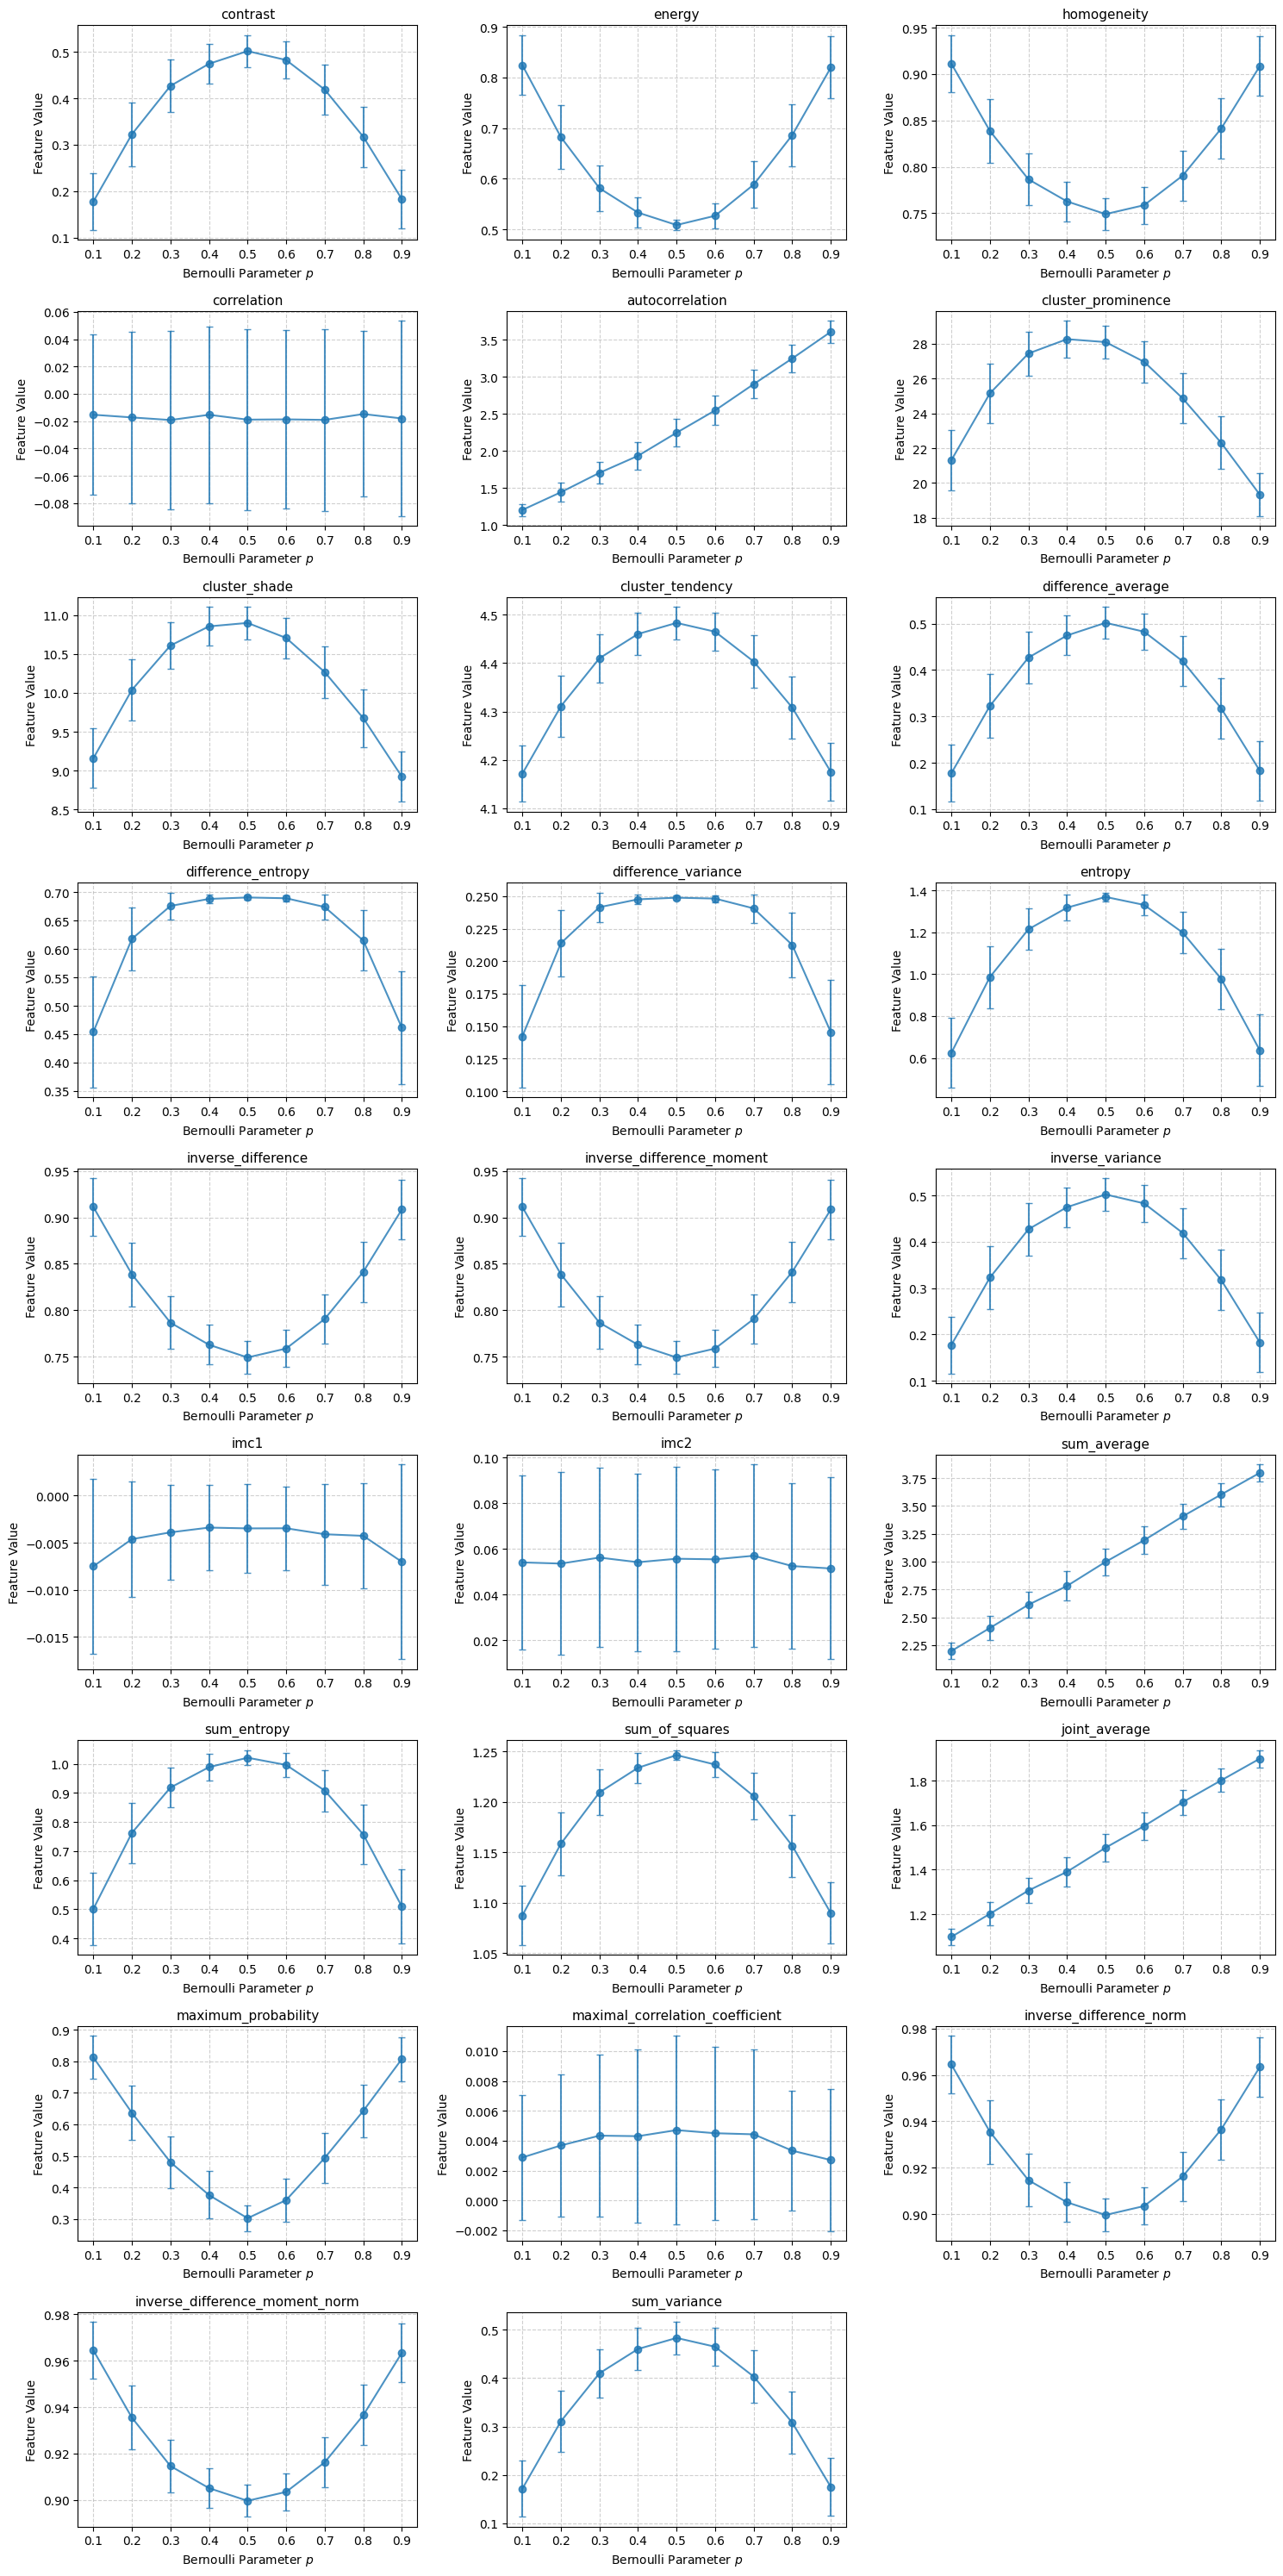

In [39]:
feature_names = [
    "contrast", "energy", "homogeneity", "correlation", 
    "autocorrelation", 
    "cluster_prominence", "cluster_shade", "cluster_tendency", 
    "difference_average", "difference_entropy", "difference_variance",
    "entropy", "inverse_difference", "inverse_difference_moment", "inverse_variance", 
    "imc1", "imc2",
    "sum_average", "sum_entropy", "sum_of_squares", 
    "joint_average", "maximum_probability", "maximal_correlation_coefficient", 
    "inverse_difference_norm", "inverse_difference_moment_norm", "sum_variance"
]

fig, axes = plt.subplots(9, 3, figsize=(15, 30))
axes = axes.flatten()

for i, name in enumerate(feature_names):
    
    avg_feat = [np.mean([f[i] for f in sample_features[p]]) for p in BERNOULLI_SETTINGS]
    std_feat = [np.std([f[i] for f in sample_features[p]]) for p in BERNOULLI_SETTINGS]

    ax = axes[i]
    ax.errorbar(
        BERNOULLI_SETTINGS,
        avg_feat,
        yerr=std_feat,
        marker='o',
        capsize=3,
        alpha=0.8
    )

    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Bernoulli Parameter $p$")
    ax.set_ylabel("Feature Value")
    ax.grid(True, linestyle='--', alpha=0.6)

for j in range(len(feature_names), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()